# Визуализация данных

Визуализация - важнейший инструмент аналитика. В Python основными библиотеками для визуализации являются `matplotlib` (базовые графики) и `seaborn` (статистические графики и более красивый дизайн по умолчанию).

Подготовим наши данные для работы.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_csv("analysis_data/df_orders.csv")
events = pd.read_csv("analysis_data/df_events.csv")


В этом уроке будет вызов огромного количества методов из pyplot, с кучей параметров. Их не нужно зубрить и запоминать! Цель - понять какие бывают графики, в идеале запомнить их названия, чтобы когда тебе потребуется что-то визуализировать, не тратить много времени объясняясь с нейронкой что ты хочешь. Никто вручную не пишет все эти методы, я ещё до времён нейронок весь код для визуализаций копировал в готовом виде с стаковерфлоу и подобных сайтов, потому что он однотипен и ты сходу можешь понять как его модифицировать под твою задачу.

Что нужно запомнить из урока:
- Какие графики бывают
- Какой тип графиков для какой задачи лучше подходит
- Графики можно настраивать почти любым образом, главное сформулировать запрос в нейронку или найти в документации нужный параметр

## Линейные графики в Matplotlib
Основа matplotlib - это модуль `pyplot`. С его помощью можно легко строить графики, передавая массивы `x` и `y`.
Для создания фигуры определенного размера используется `plt.figure(figsize=(width, height))`.


In [ ]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.figure(figsize=(6, 4))
plt.plot(x, y, color="crimson", linewidth=3, linestyle="--", label="y = x^2")
plt.title("Пример графика в Matplotlib")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


### График временного ряда
Построим динамику заказов по дням. Сначала агрегируем данные (собираем статистику по дням), затем передадим их в `plot()`.


In [ ]:
orders_daily = (
    df.assign(event_date=pd.to_datetime(df["event_date"]))
    .groupby(pd.Grouper(key="event_date", freq="D"))
    .agg(orders_cnt=("order_id", "nunique"))
    .reset_index()
)
orders_daily[:10]

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(orders_daily['event_date'], orders_daily['orders_cnt'], marker='o', linestyle='-')

ax.set_xlabel('Дата')
ax.set_ylabel('Кол-во заказов')
ax.set_title('Динамика заказов по дням')
ax.grid(True)

# Форматирование дат на оси X для красоты
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Диаграммы рассеяния (Scatter plot) и Гистограммы
Scatter plot позволяет увидеть взаимосвязь двух числовых переменных, отображая их как точки на плоскости.


In [ ]:
plt.figure(figsize=(5, 4))
# alpha задает прозрачность точек, s - размер
plt.scatter(df["order_sum"], df["commission"], alpha=0.2, s=10)
plt.title("Зависимость комиссии от суммы заказа")
plt.xlabel("Сумма заказа")
plt.ylabel("Комиссия")
plt.show()


Гистограмма показывает распределение одной числовой переменной. Данные разбиваются на корзины (`bins`), и показывается количество наблюдений в каждой корзине.


In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(df["order_sum"], bins=30, edgecolor="white", alpha=0.9)
plt.title("Распределение суммы заказа")
plt.xlabel("Сумма заказа")
plt.ylabel("Количество")
plt.show()


## Круговые и столбчатые диаграммы (Pie chart & Bar plot)
Круговая диаграмма хорошо подходит для отображения долей от целого (когда категорий немного).


In [ ]:
fee_share = (
    df["delivery_fee"]
    .value_counts()
    .reset_index(name="count")
)
fee_share

In [ ]:
plt.figure(figsize=(5, 4))
# autopct позволяет автоматически выводить проценты
plt.pie(fee_share["count"], labels=fee_share["delivery_fee"], autopct="%.1f%%")
plt.title("Доли стоимости доставки")
plt.show()


Для сравнения категорий часто лучше подходит столбчатая диаграмма (Bar plot). В `seaborn` её построение выглядит лаконичнее.


In [ ]:
event_counts = (
    events["event_type"]
    .value_counts()
    .reset_index(name="count")
)
event_counts

In [ ]:
plt.figure(figsize=(8, 3))
sns.barplot(data=event_counts, x="event_type", y="count")
plt.title("Количество событий по типам")
plt.xticks(rotation=45)
plt.show()


## Продвинутые графики Seaborn
В seaborn легко добавить группировку по цвету (`hue`), чтобы увидеть зависимость в разрезе категорий.


In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="order_sum", y="commission", hue="delivery_fee")
plt.title("Сумма заказа vs Комиссия с разбивкой по доставке")
plt.show()


Ящик с усами (Boxplot) отлично показывает распределение числовой переменной в разрезе категорий. Видно медиану, квартили и выбросы.


In [ ]:
df["delivery_fee"].unique()

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="delivery_fee", y="order_sum", order=sorted(df["delivery_fee"].dropna().unique()))
plt.title("Распределение сумм заказа по стоимости доставки")
plt.show()


Pairplot строит все возможные диаграммы рассеяния для числовых признаков, а на диагонали показывает их распределения.


In [ ]:
sns.pairplot(data=df[["order_sum", "commission", "delivery_fee"]])
plt.show()


## Корреляция и Тепловая карта (Heatmap)
Метод `.corr()` считает коэффициент корреляции (зависимости) между признаками. Тепловая карта помогает визуализировать матрицу корреляций.


In [ ]:
corr = df[["order_sum", "commission", "delivery_fee"]].corr()

plt.figure(figsize=(5, 4))
# annot=True выводит значения, cmap - цветовая схема
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Матрица корреляций")
plt.show()


# Практические задания

Пока что просто разомнёмся, а в проекте по аналитике ты сможешь применить полученные знания

### Задание 1: Линейный график
Построй линейный график динамики суммы заказов по дням


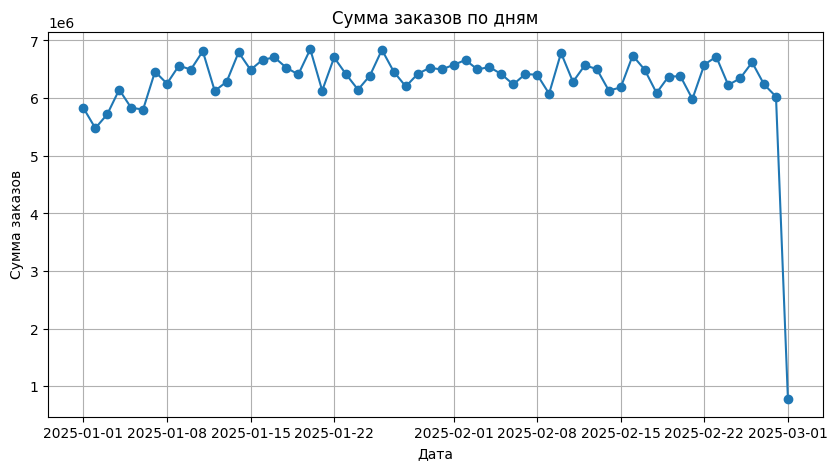

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_csv("analysis_data/df_orders.csv")
events = pd.read_csv("analysis_data/df_events.csv")
df_result = (
    df
    .assign(event_date=pd.to_datetime(df["event_date"]))
    .groupby(pd.Grouper(key="event_date", freq="D"))
    .agg(summary=("order_sum", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_result['event_date'], df_result['summary'], marker='o', linestyle='-')

ax.set_xlabel('Дата')
ax.set_ylabel('Сумма заказов')
ax.set_title('Сумма заказов по дням')
ax.grid(True)


### Задание 2: Гистограмма
Построй гистограмму распределения комиссии `commission` в датафрейме `df`. Поставь биновку 40 (`bins=40`).


Text(0, 0.5, 'Количество заказов')

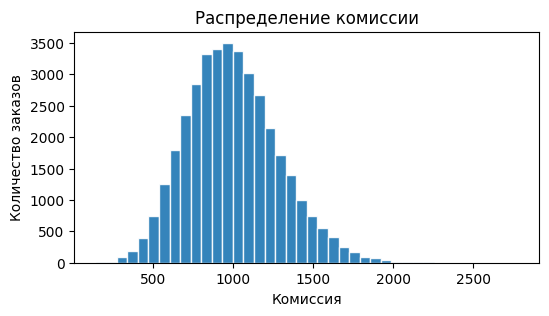

In [18]:
df[:1]
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(
    df["commission"],
    bins=40,
    edgecolor="white",
    alpha=0.9
)

ax.set_title("Распределение комиссии")
ax.set_xlabel("Комиссия")
ax.set_ylabel("Количество заказов")

### Задание 3: Boxplot
Построй Boxplot для комиссии (`commission`) в разрезе стоимости доставки (`delivery_fee`) с помощью Seaborn.


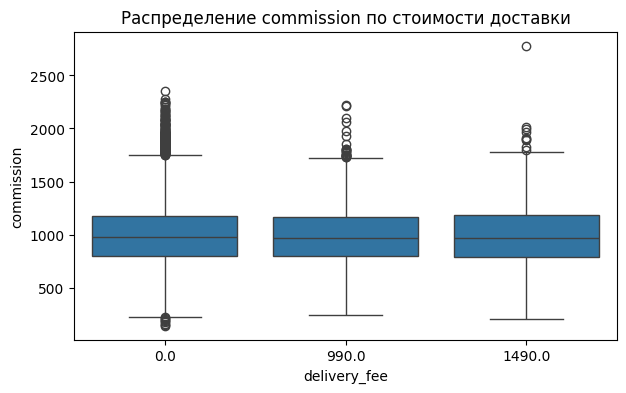

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="delivery_fee", y="commission", order=sorted(df["delivery_fee"].dropna().unique()))
plt.title("Распределение commission по стоимости доставки")
plt.show()
